# Predicción del GRD — Clasificación multiclase (Top-20)

Este notebook amplía el análisis base (que solo consideraba las cesáreas `146101/146102/146103`)
a una clasificación multiclase sobre los **20 GRD más frecuentes** del dataset,
usando los códigos de diagnóstico (CIE-10) y procedimiento (CIE-9-CM) de cada egreso,
más edad y sexo.

**Problema:** dado el conjunto de diagnósticos y procedimientos de una hospitalización
(y la edad y sexo del paciente), predecir el GRD que FONASA le asignó al egreso.

**Modelos comparados:** Regresión Logística, Random Forest, XGBoost y una LSTM sobre la
secuencia tokenizada de códigos clínicos. Evaluación con accuracy, precisión, recall y F1
(macro y weighted) sobre particiones train/val/test estratificadas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", message=".*urllib3 v2 only supports OpenSSL.*")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import json
from collections import Counter
from datetime import datetime
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 200)

%matplotlib inline

ModuleNotFoundError: No module named 'tensorflow'

## 1. Carga y limpieza de datos

Se replica la limpieza del notebook base: de cada celda se conserva solo el **código** (se recorta la descripción tras el guion `-`) y se renombran las columnas `Diag XX` → `DiagXX` y `Proced XX` → `ProcedXX`.

In [2]:
DATA_PATH = "dataset/dataset_elpino.csv"
N_TOP = 20

with open(DATA_PATH, encoding="utf-8") as f:
    header = f.readline().strip().split(";")

def clean_colname(col):
    col = col.split("-")[0].strip()
    if col.startswith("Diag") or col.startswith("Proc"):
        partes = col.split(" ")
        col = partes[0] + partes[1]
    return col

features = [clean_colname(c) for c in header]
diag_cols = [c for c in features if c.startswith("Diag")]
proc_cols = [c for c in features if c.startswith("Proced")]

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8", names=features, skiprows=1, dtype=str)

def clean_codes(s):
    return s.str.split("-", n=1).str[0].str.strip()

for c in diag_cols + proc_cols:
    df[c] = clean_codes(df[c])

df["Edad"] = pd.to_numeric(df["Edad en años"], errors="coerce")
df["Sexo"] = df["Sexo (Desc)"].map({"Mujer": 1, "Hombre": 0})
df["GRD"] = clean_codes(df["GRD"])
df = df[diag_cols + proc_cols + ["Edad", "Sexo", "GRD"]]

print("Filas con edad no parseable:", df["Edad"].isna().sum())
df = df.dropna(subset=["Edad"]).copy()
df["Edad"] = df["Edad"].astype(int)

print("Forma final:", df.shape)
df.head()

Filas con edad no parseable: 0
Forma final: (14561, 68)


,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,Diag11,Diag12,Diag13,Diag14,Diag15,Diag16,Diag17,Diag18,Diag19,Diag20,Diag21,Diag22,Diag23,Diag24,Diag25,Diag26,Diag27,Diag28,Diag29,Diag30,Diag31,Diag32,Diag33,Diag34,Diag35,Proced01,Proced02,Proced03,Proced04,Proced05,Proced06,Proced07,Proced08,Proced09,Proced10,Proced11,Proced12,Proced13,Proced14,Proced15,Proced16,Proced17,Proced18,Proced19,Proced20,Proced21,Proced22,Proced23,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,Edad,Sexo,GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,U07.1,Y95,N18.5,E87.1,D64.9,G82.2,N31.9,I10,K70.4,F19.2,F10.2,E46,G40.9,L21.9,Z93.5,Z93.3,Z99.2,Z91.6,,,,,,,,86.28,34.91,88.38,87.41,88.75,88.01,88.43,88.41,87.44,99.29,99.19,99.18,99.21,99.26,99.23,93.94,89.52,90.59,89.65,39.95,39.95,99.04,90.39,99.84,88.72,90.42,90.52,91.39,91.33,87.03,40,0,184103
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,J15.1,Y95,N17.9,G62.8,M54.19,L89.3,F13.2,,,,,,,,,,,,,,,,,,,31.1,86.28,96.72,93.90,89.7,88.01,87.41,34.04,88.43,93.96,93.94,90.39,99.84,99.29,99.19,00.17,99.21,99.18,99.26,99.23,89.65,91.69,87.44,91.62,90.43,91.39,90.52,91.32,96.59,90.99,53,0,041013
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,J99.8,J69.0,A49.0,L89.3,B96.4,E11.1,E87.0,E87.6,E83.5,N17.9,K75.9,D64.9,E46,E87.3,J44.8,J98.4,U07.1,Z29.0,Z01.7,Z20.8,Z88.0,Z72.0,,,,86.22,54.59,96.72,31.1,45.13,87.41,87.03,88.01,88.43,88.72,33.22,87.44,89.7,90.59,00.17,99.21,99.04,93.96,91.83,90.43,38.93,91.33,90.39,99.84,91.73,90.53,99.26,89.39,89.66,89.65,65,0,041013
3,K76.8,K66.1,N18.5,D64.9,E87.5,E87.2,J81,N17.8,J44.9,R41.0,K44.9,K26.9,B96.2,R57.1,K80.2,L89.0,F12.2,Z91.1,Z99.2,,,,,,,,,,,,,,,,,54.19,39.98,86.28,54.62,96.72,96.04,87.41,88.01,88.38,88.41,88.47,87.44,88.75,88.79,88.72,89.52,45.13,38.93,38.91,38.95,39.95,96.59,94.19,57.94,00.13,00.17,99.04,99.18,99.21,99.23,61,0,041023
4,T81.0,Y83.2,S31.1,S36.80,W31.62,J96.09,J15.0,U82.2,U07.1,N39.0,B96.2,Y95,D62,N17.9,E87.6,K70.4,I85.9,G93.4,R18,I10,F10.2,F19.2,,,,,,,,,,,,,,54.11,45.90,46.73,46.20,86.28,54.19,89.7,96.04,96.72,54.4,88.47,88.01,87.44,99.04,93.94,93.96,00.13,00.17,99.18,99.26,99.19,99.21,99.29,90.52,91.39,91.32,93.90,99.15,96.59,45.13,30,0,041023


## 2. Selección de las 20 clases

In [3]:
mapper = {}
try:
    grd_tabla = pd.read_excel("dataset/IR-GRD V3.1 CON PRECIOS FONASA 2016.xlsx")
    mapper = dict(zip(grd_tabla["IR-GRD CÓDIGO"].astype(int), grd_tabla["NOMBRE DEL GRUPO GRD"]))
except Exception as e:
    print("No se pudo leer la tabla maestra de GRD:", e)

top_grd = df["GRD"].value_counts().head(N_TOP)
top_grd_names = top_grd.index.tolist()
data = df[df["GRD"].isin(top_grd_names)].copy()
data["GRD_et"] = data["GRD"].apply(lambda c: f"{c} - {mapper.get(int(c), '?')}".rstrip())

print(f"Egresos retenidos: {len(data)} de {len(df)}  ({len(data)/len(df)*100:.1f}%)")
print(f"Clases distintas: {data['GRD'].nunique()}")

tabla = pd.DataFrame({
    "GRD": top_grd.index,
    "Egresos": top_grd.values,
    "Descripción": [mapper.get(int(c), "")[:60] for c in top_grd.index],
})
tabla

Egresos retenidos: 5861 de 14561  (40.3%)
Clases distintas: 20


,GRD,Egresos,Descripción
0,146101,813,PH CESÁREA
1,146121,639,"PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILI..."
2,146131,538,PH PARTO VAGINAL
3,158171,389,"MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDI..."
4,134161,325,MH TRASTORNOS DEL ANTEPARTO
5,071141,317,PH COLECISTECTOMÍA LAPAROSCÓPICA
6,044153,287,MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W...
7,061131,252,PH PROCEDIMIENTOS SOBRE APÉNDICE
8,041023,248,PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEO...
9,146102,244,PH CESÁREA W/CC


## 3. Análisis exploratorio de datos (EDA)

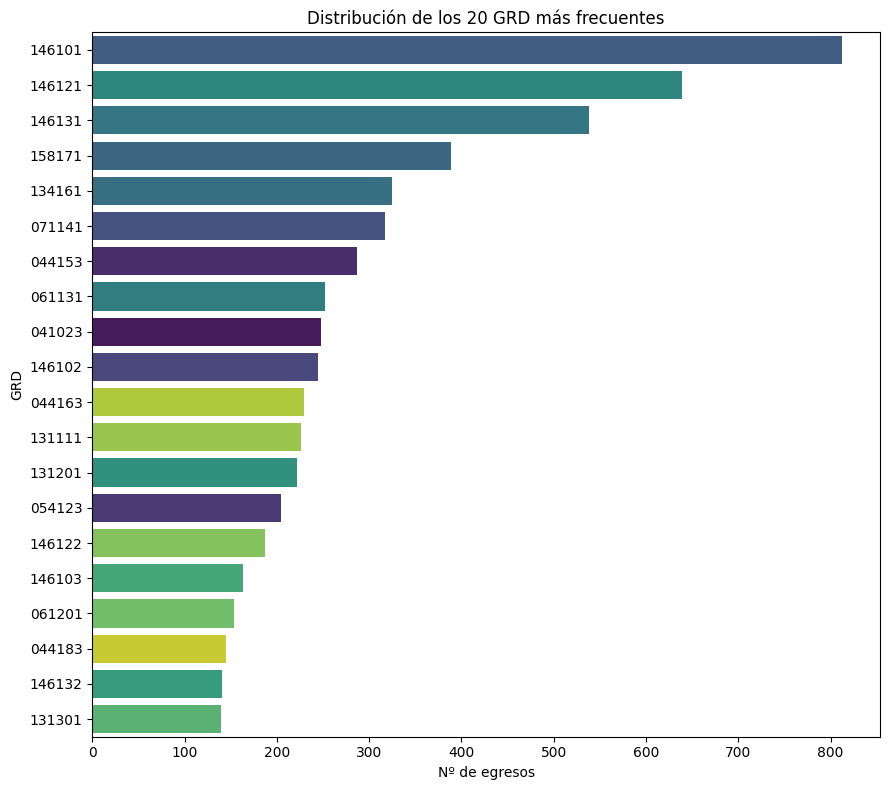

In [4]:
plt.figure(figsize=(9, 8))
sns.countplot(data=data, y="GRD", order=data["GRD"].value_counts().index,
              hue="GRD", palette="viridis", legend=False)
plt.xlabel("Nº de egresos")
plt.ylabel("GRD")
plt.title(f"Distribución de los {N_TOP} GRD más frecuentes")
plt.tight_layout()
plt.show()

### 3.1 Completitud de los datos

Cada egreso puede traer hasta 35 diagnósticos y 30 procedimientos. El `-` (celda vacía) indica que esa posición no se usó.

Diagnósticos por egreso:
count    5861
mean        7
std         5
min         1
25%         3
50%         8
75%        10
max        35

Procedimientos por egreso:
count    5861
mean       12
std         6
min         1
25%         9
50%        12
75%        14
max        30


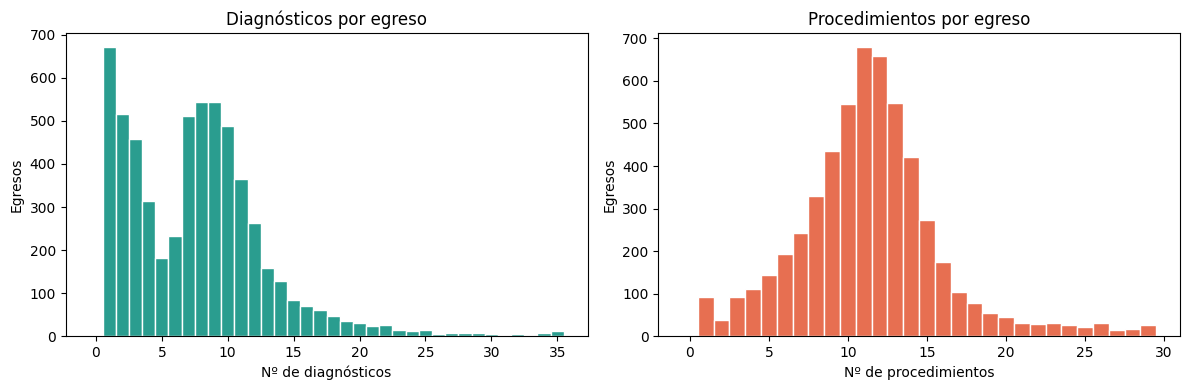

In [5]:
n_diag = data[diag_cols].apply(lambda s: (s != "").sum(), axis=1)
n_proc = data[proc_cols].apply(lambda s: (s != "").sum(), axis=1)

print("Diagnósticos por egreso:")
print(n_diag.describe().astype(int).to_string())
print("\nProcedimientos por egreso:")
print(n_proc.describe().astype(int).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(n_diag, bins=np.arange(-0.5, 36.5, 1), edgecolor="white", color="#2a9d8f")
axes[0].set_xlabel("Nº de diagnósticos"); axes[0].set_ylabel("Egresos")
axes[0].set_title("Diagnósticos por egreso")
axes[1].hist(n_proc, bins=np.arange(-0.5, 30.5, 1), edgecolor="white", color="#e76f51")
axes[1].set_xlabel("Nº de procedimientos"); axes[1].set_ylabel("Egresos")
axes[1].set_title("Procedimientos por egreso")
plt.tight_layout(); plt.show()

### 3.2 Códigos clínicos más frecuentes

In [6]:
cnt_diag = Counter(data[diag_cols].to_numpy().flatten().tolist())
cnt_proc = Counter(data[proc_cols].to_numpy().flatten().tolist())

try:
    cie10 = pd.read_excel("dataset/CIE-10.xlsx"); d10 = dict(zip(cie10["Código"].astype(str), cie10["Descripción"]))
except Exception:
    d10 = {}
try:
    cie9 = pd.read_excel("dataset/CIE-9.xlsx"); d9 = dict(zip(cie9["Código"].astype(str), cie9["Descripción"]))
except Exception:
    d9 = {}

for cnt, dct, n, title in [(cnt_diag, d10, 12, "Diagnósticos más frecuentes (CIE-10)"),
                           (cnt_proc, d9, 12, "Procedimientos más frecuentes (CIE-9-CM)")]:
    print(f"===== {title} =====")
    for cod, c in cnt.most_common(n):
        if not cod:
            continue
        print(f"  {cod:8s} {c:5d}   {dct.get(cod, '')[:60]}")

===== Diagnósticos más frecuentes (CIE-10) =====
  Z39.2     2721   Seguimiento postparto, de rutina
  Z39.0     2719   Atención y examen inmediatamente después del parto
  Z39.1     2709   Atención y examen de madre en período de lactancia
  Z38.0     2685   Producto único, nacido en hospital
  Z37.0     2677   Nacido vivo, único
  O80.0     1381   Parto único espontáneo, presentación cefálica de vértice
  E66.9     1014   Obesidad, no especificada
  O99.2      982   Enfermedades endocrinas, de la nutrición y del metabolismo q
  I10        777   Hipertensión esencial (primaria)
  O70.0      754   Desgarro perineal de primer grado durante el parto
  O82.1      714   Parto por cesárea de emergencia
===== Procedimientos más frecuentes (CIE-9-CM) =====
  90.59     5228   EXAMEN MICROSCOPICO SANGRE.OTRO
  89.7      4433   EXAMEN FISICO GENERAL
  99.29     4132   INYECCION SUSTANCIA TERAPEUTICA O PROFILACTICA.OTRA
  90.39     4053   EXAMEN MICROSCOPICO ORL.OTRO
  99.18     3957   INYECCION 

### 3.3 Edad y Sexo por GRD

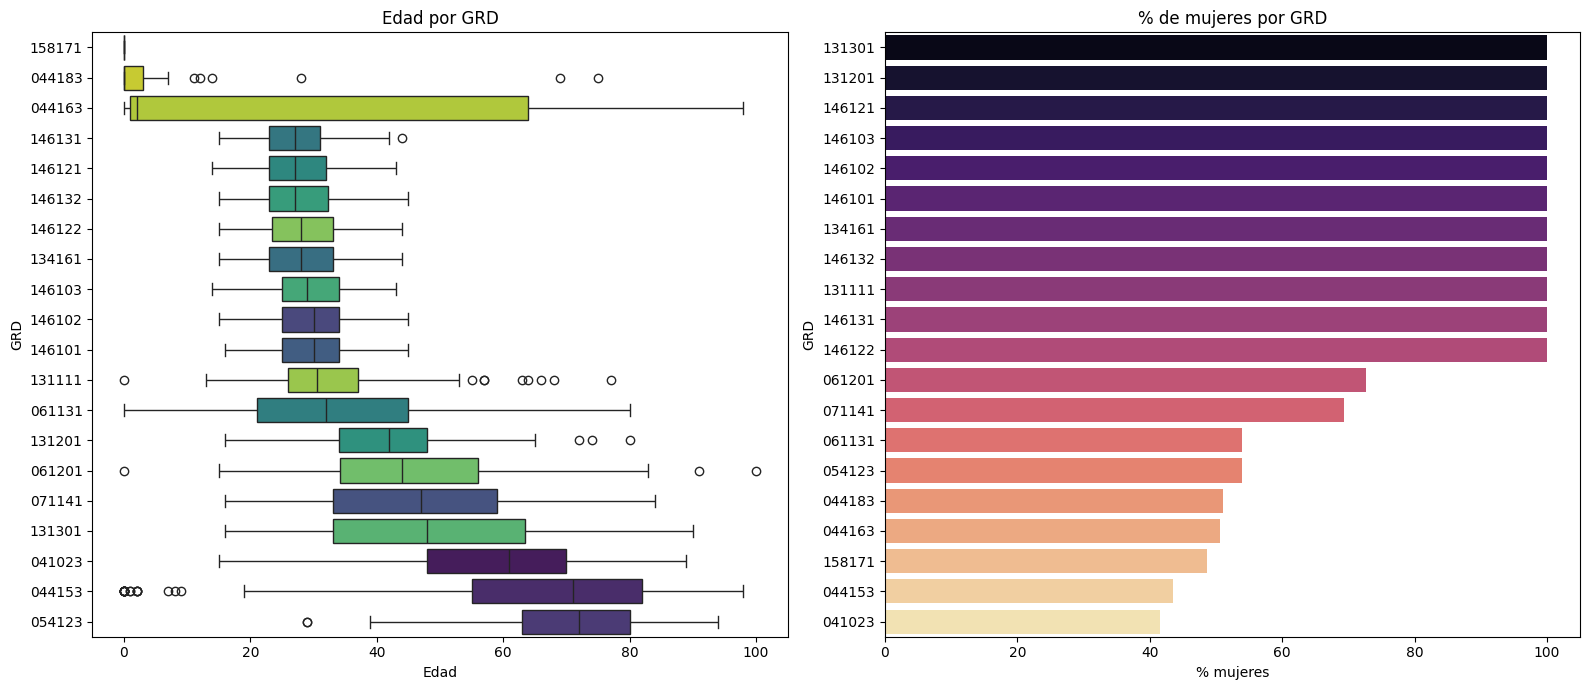

Edad (global):
count    5861.0
mean       33.1
std        20.4
min         0.0
25%        23.0
50%        30.0
75%        40.0
max       100.0
Sexo: {1: 4821, 0: 1040}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
order_age = data.groupby("GRD")["Edad"].median().sort_values().index
sns.boxplot(data=data, x="Edad", y="GRD", order=order_age, hue="GRD",
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Edad por GRD")

pct_mujer = (data.groupby("GRD")["Sexo"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=pct_mujer.values, y=pct_mujer.index, hue=pct_mujer.index,
            palette="magma", legend=False, ax=axes[1])
axes[1].set_title("% de mujeres por GRD"); axes[1].set_xlabel("% mujeres")
plt.tight_layout(); plt.show()

print("Edad (global):")
print(data["Edad"].describe().round(1).to_string())
print("Sexo:", data["Sexo"].value_counts().to_dict())

## 4. Ingeniería de características

Se construyen dos representaciones:

1. **Secuencia de tokens** (para la LSTM): cada código clínico se reemplaza por un id según su frecuencia (como en el notebook base).
2. **Vector multi-hot** (para modelos clásicos): una dimensión binaria por cada código del vocabulario.

En ambos casos se agregan **Edad** (normalizada) y **Sexo** como variables numéricas.

In [8]:
data[diag_cols + proc_cols] = data[diag_cols + proc_cols].fillna("")

freq_d = data[diag_cols].apply(pd.Series.value_counts).sum(axis=1).drop(index="", errors="ignore")
freq_p = data[proc_cols].apply(pd.Series.value_counts).sum(axis=1).drop(index="", errors="ignore")
diag_sorted = freq_d.sort_values(ascending=False).index.tolist()
proc_sorted = freq_p.sort_values(ascending=False).index.tolist()
n_diag, n_proc = len(diag_sorted), len(proc_sorted)
VOCAB = n_diag + n_proc + 1

tok_d = {c: i + 1 for i, c in enumerate(diag_sorted)}
tok_p = {c: n_diag + i + 1 for i, c in enumerate(proc_sorted)}

token_rows = []
for _, r in data.iterrows():
    toks = [tok_d[r[c]] for c in diag_cols if r[c] in tok_d]
    toks += [tok_p[r[c]] for c in proc_cols if r[c] in tok_p]
    token_rows.append(toks)

def multi_hot(tokens, size=VOCAB):
    v = np.zeros(size, dtype=np.float32)
    if tokens:
        v[np.asarray(tokens, dtype=int)] = 1.0
    return v

X_seq = pad_sequences(token_rows, padding="post")
X_codes = np.stack([multi_hot(t) for t in token_rows])
meta = np.column_stack([data["Edad"].to_numpy(dtype=float),
                        data["Sexo"].to_numpy(dtype=float)])

le = LabelEncoder()
y = le.fit_transform(data["GRD"])
n_classes = len(le.classes_)

token_names = [""] + diag_sorted + proc_sorted
print(f"Diagnósticos distintos: {n_diag} | Procedimientos: {n_proc} | Vocabulario: {VOCAB}")
print("X_seq:", X_seq.shape, "| X_codes:", X_codes.shape, "| meta:", meta.shape, "| y:", y.shape, "| clases:", n_classes)

Diagnósticos distintos: 1749 | Procedimientos: 500 | Vocabulario: 2250
X_seq: (5861, 65) | X_codes: (5861, 2250) | meta: (5861, 2) | y: (5861,) | clases: 20


## 5. Partición train / val / test (estratificada por GRD)

In [9]:
idx = np.arange(len(data))
idx_train, idx_tmp, y_train, y_tmp = train_test_split(idx, y, test_size=0.30,
                                                      stratify=y, random_state=SEED)
idx_val, idx_test, y_val, y_test = train_test_split(idx_tmp, y_tmp, test_size=0.5,
                                                    stratify=y_tmp, random_state=SEED)

sc = StandardScaler().fit(meta[idx_train])
meta_s = sc.transform(meta)

Xclas_train = np.hstack([X_codes[idx_train], meta_s[idx_train]])
Xclas_val   = np.hstack([X_codes[idx_val],   meta_s[idx_val]])
Xclas_test  = np.hstack([X_codes[idx_test],  meta_s[idx_test]])

Xseq_train, Xseq_val, Xseq_test = X_seq[idx_train], X_seq[idx_val], X_seq[idx_test]
meta_train, meta_val, meta_test = meta_s[idx_train], meta_s[idx_val], meta_s[idx_test]

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print("Distribución de clases en train:", dict(zip(*np.unique(y_train, return_counts=True))))

Train: 4102 | Val: 879 | Test: 880
Distribución de clases en train: {np.int64(0): np.int64(174), np.int64(1): np.int64(201), np.int64(2): np.int64(160), np.int64(3): np.int64(102), np.int64(4): np.int64(143), np.int64(5): np.int64(176), np.int64(6): np.int64(108), np.int64(7): np.int64(222), np.int64(8): np.int64(158), np.int64(9): np.int64(155), np.int64(10): np.int64(97), np.int64(11): np.int64(227), np.int64(12): np.int64(569), np.int64(13): np.int64(171), np.int64(14): np.int64(114), np.int64(15): np.int64(447), np.int64(16): np.int64(131), np.int64(17): np.int64(377), np.int64(18): np.int64(98), np.int64(19): np.int64(272)}


## 6. Modelos de línea base y clásicos

Se evalúa primero un *dummy* (clase mayoritaria) como referencia, y luego tres modelos clásicos sobre la representación multi-hot + edad + sexo. Las métricas se calculan sobre **validación**.

In [10]:
resultados = []

def metricas(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision (macro)": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Recall (macro)": round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "F1 (macro)": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "F1 (weighted)": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
    }

In [11]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(Xclas_train, y_train)
resultados.append(metricas("Dummy (mayoritaria)", y_val, dummy.predict(Xclas_val)))

lr = LogisticRegression(max_iter=1000, C=1.0, solver="liblinear", random_state=SEED)
_old_err = np.seterr(all="ignore")
lr.fit(Xclas_train, y_train)
res_lr = metricas("Regresión Logística", y_val, lr.predict(Xclas_val))
np.seterr(**_old_err)
resultados.append(res_lr)
print("OK LogisticRegression")

OK LogisticRegression


In [12]:
rf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=SEED)
rf.fit(Xclas_train, y_train)
resultados.append(metricas("Random Forest", y_val, rf.predict(Xclas_val)))
print("OK RandomForest")

OK RandomForest


In [13]:
xgb = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric="mlogloss", random_state=SEED, n_jobs=-1)
xgb.fit(Xclas_train, y_train, eval_set=[(Xclas_val, y_val)], verbose=False)
resultados.append(metricas("XGBoost", y_val, xgb.predict(Xclas_val)))
print("OK XGBoost")

OK XGBoost


## 7. Modelo secuencial (LSTM + Embedding)

La LSTM recibe la **secuencia** de códigos clínicos (longitud 65), y se le concatenan la edad y el sexo codificados en una rama densa pequeña.

In [14]:
seq_len = Xseq_train.shape[1]

def build_lstm(vocab_size, seq_len, n_classes, n_meta=2):
    seq_in = Input(shape=(seq_len,), name="secuencia")
    meta_in = Input(shape=(n_meta,), name="meta")
    emb = Embedding(vocab_size, 64, mask_zero=True, name="embedding")(seq_in)
    lstm = LSTM(64, return_sequences=False, name="lstm")(emb)
    mi = Dense(16, activation="relu", name="meta_dense")(meta_in)
    x = Concatenate(name="concat")([lstm, mi])
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation="softmax", name="salida")(x)
    return Model(inputs=[seq_in, meta_in], outputs=out)

modelo_lstm = build_lstm(VOCAB, seq_len, n_classes)
modelo_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ secuencia           │ (None, 65)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 65, 64)    │    144,000 │ secuencia[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 65)        │          0 │ secuencia[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta (InputLayer)   │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_dense (Dense)  │ (None, 16)        │         48 │ meta[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 80)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ meta_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 80)        │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida (Dense)      │ (None, 20)        │      1,620 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 178,692 (698.02 KB)

 Trainable params: 178,692 (698.02 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [15]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
hist = modelo_lstm.fit(
    {"secuencia": Xseq_train, "meta": meta_train}, y_train,
    validation_data=({"secuencia": Xseq_val, "meta": meta_val}, y_val),
    epochs=60, batch_size=64, callbacks=[es], verbose=1)

Epoch 1/60


 1/65 ━━━━━━━━━━━━━━━━━━━━ 1:11 1s/step - accuracy: 0.0469 - loss: 3.0230

 6/65 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0360 - loss: 3.0346

11/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0410 - loss: 3.0309

16/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0532 - loss: 3.0255

...

46/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9869 - loss: 0.0564

51/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9868 - loss: 0.0562

56/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9867 - loss: 0.0561

61/65 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9867 - loss: 0.0560

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9868 - loss: 0.0558 - val_accuracy: 0.9261 - val_loss: 0.2854


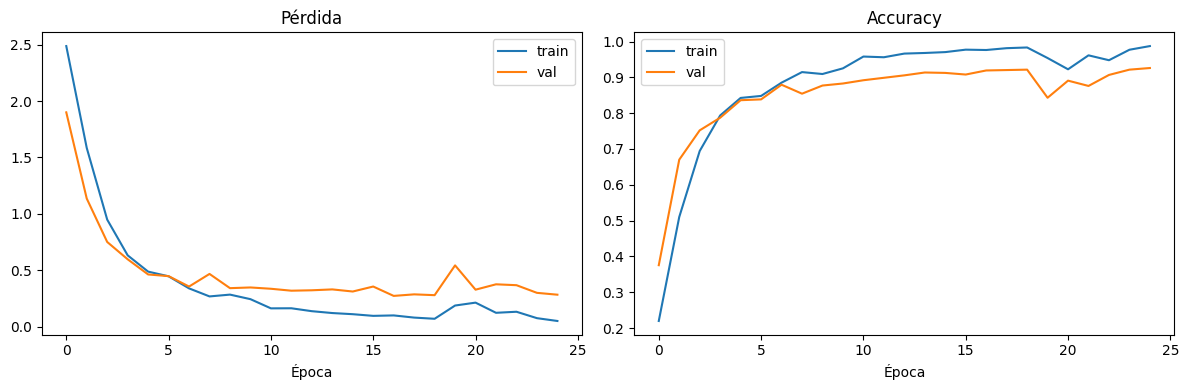

Mejor val_loss: 0.2748 en época 17


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist.history["loss"], label="train")
axes[0].plot(hist.history["val_loss"], label="val")
axes[0].set_title("Pérdida"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].plot(hist.history["accuracy"], label="train")
axes[1].plot(hist.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Mejor val_loss: {:.4f} en época {}".format(
    min(hist.history["val_loss"]), np.argmin(hist.history["val_loss"]) + 1))

In [17]:
y_pred_lstm = np.argmax(modelo_lstm.predict(
    {"secuencia": Xseq_val, "meta": meta_val}, verbose=0), axis=1)
resultados.append(metricas("LSTM (emb+seq)", y_val, y_pred_lstm))
print("OK LSTM")

OK LSTM


## 8. Comparación de modelos (validación)

In [18]:
df_val = pd.DataFrame(resultados).set_index("Modelo")
df_val.sort_values("F1 (macro)", ascending=False)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
LSTM (emb+seq),0.9192,0.9117,0.8891,0.8982,0.9177
Regresión Logística,0.9181,0.9268,0.8824,0.8962,0.9136
XGBoost,0.9181,0.9170,0.8799,0.8918,0.9135
Random Forest,0.8692,0.8634,0.7937,0.7967,0.8411
Dummy (mayoritaria),0.1388,0.0069,0.0500,0.0122,0.0338


## 9. Evaluación final sobre el conjunto de test

Para evitar sesgo de selección, las métricas decisivas se calculan sobre el conjunto de **test** (no visto durante la selección de hiperparámetros ni la elección de modelo).

In [19]:
modelos = {
    "Dummy (mayoritaria)": lambda X: dummy.predict(X),
    "Regresión Logística": lambda X: lr.predict(X),
    "Random Forest": lambda X: rf.predict(X),
    "XGBoost": lambda X: xgb.predict(X),
}

res_test = []
y_prob_lstm_test = modelo_lstm.predict({"secuencia": Xseq_test, "meta": meta_test}, verbose=0)
res_lstm_test = metricas("LSTM (emb+seq)", y_test, np.argmax(y_prob_lstm_test, axis=1))

_old_err = np.seterr(all="ignore")
for nombre, fn in modelos.items():
    res_test.append(metricas(nombre, y_test, fn(Xclas_test)))
np.seterr(**_old_err)
res_test.append(res_lstm_test)

df_test = pd.DataFrame(res_test).set_index("Modelo")
df_test.sort_values("F1 (macro)", ascending=False)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
LSTM (emb+seq),0.9443,0.9320,0.9339,0.9320,0.9436
XGBoost,0.9420,0.9344,0.9251,0.9281,0.9404
Regresión Logística,0.9284,0.9340,0.9024,0.9126,0.9241
Random Forest,0.8705,0.9260,0.8041,0.8008,0.8364
Dummy (mayoritaria),0.1386,0.0069,0.0500,0.0122,0.0338


In [20]:
mejor_test = df_test["F1 (macro)"].idxmax()
print("Mejor modelo en test (F1 macro):", mejor_test)

if "LSTM" in mejor_test:
    y_pred_best = np.argmax(modelo_lstm.predict({"secuencia": Xseq_test, "meta": meta_test}, verbose=0), axis=1)
elif mejor_test == "Random Forest":
    y_pred_best = rf.predict(Xclas_test)
elif mejor_test == "XGBoost":
    y_pred_best = xgb.predict(Xclas_test)
else:
    y_pred_best = lr.predict(Xclas_test)

print("\nReporte por clase del mejor modelo en test:\n")
print(classification_report(y_test, y_pred_best,
                            target_names=[f"{c}" for c in le.classes_], zero_division=0))

Mejor modelo en test (F1 macro): LSTM (emb+seq)



Reporte por clase del mejor modelo en test:

              precision    recall  f1-score   support

      041023       0.97      0.89      0.93        37
      044153       0.93      0.93      0.93        43
      044163       0.97      1.00      0.99        35
      044183       0.95      1.00      0.98        21
      054123       0.90      0.93      0.92        30
      061131       0.95      1.00      0.97        38
      061201       0.96      1.00      0.98        23
      071141       1.00      0.98      0.99        48
      131111       1.00      0.91      0.95        34
      131201       0.91      0.94      0.93        33
      131301       0.83      0.90      0.86        21
      134161       0.96      0.98      0.97        49
      146101       0.94      0.96      0.95       122
      146102       0.83      0.68      0.75        37
      146103       0.88      0.88      0.88        24
      146121       0.97      0.99      0.98        96
      146122       0.89      0.86  

<Figure size 1200x1000 with 0 Axes>

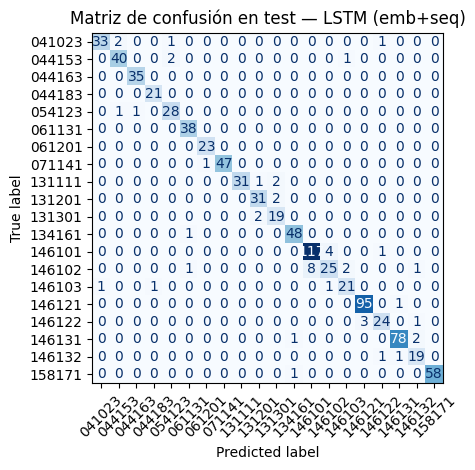

In [21]:
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=[c for c in le.classes_],
    cmap="Blues", values_format="d", colorbar=False, xticks_rotation=45)
plt.title(f"Matriz de confusión en test — {mejor_test}")
plt.tight_layout(); plt.show()

### AUC (one-vs-rest) por clase

In [22]:
if mejor_test == "Random Forest":
    y_prob_best = rf.predict_proba(Xclas_test)
elif mejor_test == "XGBoost":
    y_prob_best = xgb.predict_proba(Xclas_test)
elif "LSTM" in mejor_test:
    y_prob_best = modelo_lstm.predict({"secuencia": Xseq_test, "meta": meta_test}, verbose=0)
else:
    y_prob_best = lr.predict_proba(Xclas_test)

aucs = [roc_auc_score((y_test == c).astype(int), y_prob_best[:, c])
        for c in range(n_classes)]
res_auc = pd.DataFrame({
    "GRD": le.classes_,
    "Egresos (test)": np.bincount(y_test),
    "AUC (OvR)": np.round(aucs, 3),
}).sort_values("AUC (OvR)", ascending=False)
print(f"AUC macro promedio: {np.mean(aucs):.3f}")
res_auc

AUC macro promedio: 0.995


,GRD,Egresos (test),AUC (OvR)
19,158171,59,1.000
11,134161,49,1.000
2,044163,35,1.000
3,044183,21,1.000
5,061131,38,1.000
6,061201,23,1.000
7,071141,48,1.000
17,146131,81,0.999
0,041023,37,0.999
8,131111,34,0.999


### Importancia de características (Random Forest)

Top 20:
feature  importancia
   Edad     0.042438
  75.69     0.038280
  O70.0     0.031350
  57.94     0.019987
  51.23     0.018539
   74.1     0.018322
  73.59     0.015374
  89.26     0.015355
  O80.0     0.015120
  99.29     0.013659
  90.39     0.012159
  Z38.0     0.011966
  99.19     0.011540
  O68.1     0.011366
  Z39.0     0.011166
  97.64     0.010762
  Z37.0     0.010637
  Z39.2     0.010477
  K35.8     0.010189
  91.39     0.010084


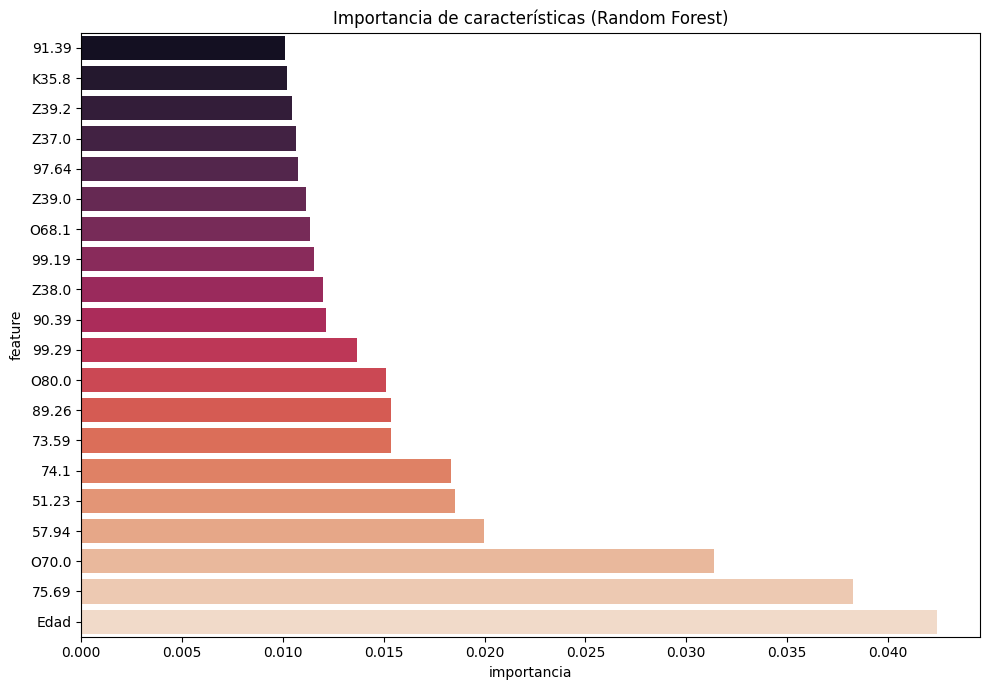

In [23]:
imp = rf.feature_importances_
cols_fi = token_names + ["Edad", "Sexo"]
fi = pd.DataFrame({"feature": cols_fi, "importancia": imp}).sort_values("importancia", ascending=False)
print("Top 20:")
print(fi.head(20).to_string(index=False))

plt.figure(figsize=(10, 7))
top_fi = fi.head(20).iloc[::-1]
sns.barplot(data=top_fi, x="importancia", y="feature", hue="feature",
            palette="rocket", legend=False)
plt.title("Importancia de características (Random Forest)")
plt.tight_layout(); plt.show()

## 10. Persistencia de los modelos

Se guardan el mejor modelo de la comparación y el mejor clásico (Random Forest), junto con el codificador de etiquetas y el escalador, para reproducir las predicciones desde el CSV.

In [24]:
ts = datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs("models", exist_ok=True)

modelo_lstm.save(f"models/multiclase_lstm_{ts}.keras")
joblib.dump(rf, f"models/multiclase_rf_{ts}.joblib", compress=3)
joblib.dump(sc, f"models/multiclase_scaler_{ts}.joblib")
np.save(f"models/multiclase_classes_{ts}.npy", le.classes_)
json.dump(token_names, open(f"models/multiclase_tokens_{ts}.json", "w"))

print("Modelos guardados en models/ con timestamp", ts)
print("LSTME:", f"models/multiclase_lstm_{ts}.keras")
print("RF:", f"models/multiclase_rf_{ts}.joblib")

Modelos guardados en modelos/ con timestamp 20260905-203334
LSTME: modelos/multiclase_lstm_20260905-203334.keras
RF: modelos/multiclase_rf_20260905-203334.joblib


## 11. Observaciones

- La distribución de clases es muy desbalanceada: incluso los 20 GRD más frecuentes no superan
  el 40% de los egresos, y dentro de ellos la clase mayoritaria (cesárea) triplica a las minoritarias.
- El incluir **Edad** y **Sexo** (que el notebook base descartaba) es especialmente relevante en grupos
  obstétricos/pediátricos vs. adultos mayores.
- La **LSTM** sobre la secuencia de códigos captura el orden (diagnóstico principal primero) y la
  co-ocurrencia de códigos, mientras que los modelos clásicos usan solo presencia/ausencia.
- El desbalance de clases favorece las métricas *weighted*; la elección del mejor modelo se basa en
  **F1 macro** para no privilegiar a la clase mayoritaria.
- Pendiente para el informe: análisis SHAP del mejor modelo, comparación con la literatura
  (e.g., predicción de DRG/APR-DRG con secuencias de códigos) y discusión de los límites
  del vocabulario de códigos como representación.